In [1]:
!pip install yfinance

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    LSTM,
    Dense,
    Dropout
)

In [24]:
data = pd.read_csv(
    '/content/NIFTY_50.csv',
    parse_dates=['Date'],
    index_col='Date'
)

In [25]:
dataset = data[['Close']]

In [26]:
scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(dataset)

In [27]:
X = []
y = []

sequence_length = 60

for i in range(sequence_length, len(scaled_data)):

    X.append(
        scaled_data[i-sequence_length:i]
    )

    y.append(
        scaled_data[i]
    )

X = np.array(X)
y = np.array(y)

In [28]:
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]


In [29]:
model = Sequential()

# First LSTM Layer
model.add(
    LSTM(
        units=64,
        return_sequences=True,
        input_shape=(X_train.shape[1], 1)
    )
)

model.add(
    Dropout(0.2)
)

# Second LSTM Layer
model.add(
    LSTM(
        units=64
    )
)

model.add(
    Dropout(0.2)
)

# Dense Output Layer
model.add(
    Dense(1)
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [30]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.0001, clipvalue=1.0),
    loss='mean_squared_error'
)

In [31]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 10s 58ms/step - loss: 0.0157 - val_loss: 0.0020
Epoch 2/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 10s 52ms/step - loss: 0.0012 - val_loss: 0.0044
Epoch 3/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 10s 52ms/step - loss: 9.2709e-04 - val_loss: 0.0027
Epoch 4/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 7s 64ms/step - loss: 8.4689e-04 - val_loss: 6.9829e-04
Epoch 5/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 6s 55ms/step - loss: 8.0308e-04 - val_loss: 7.9092e-04
Epoch 6/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 7s 64ms/step - loss: 7.9681e-04 - val_loss: 4.9918e-04
Epoch 7/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 6s 55ms/step - loss: 7.4147e-04 - val_loss: 3.7389e-04
Epoch 8/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 7s 66ms/step - loss: 6.8018e-04 - val_loss: 5.5643e-04
Epoch 9/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 6s 53ms/step - loss: 6.8193e-04 - val_loss: 3.4917e-04
Epoch 10/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 7s 64ms/step - loss: 6.2387e-04 - val_loss: 4.1548e-04
Epoch 11/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step - loss: 6.19

In [32]:
predictions = model.predict(X_test)

# Inverse scaling
predictions = scaler.inverse_transform(
    predictions
)

y_test_actual = scaler.inverse_transform(
    y_test
)

28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step


In [33]:
rmse = np.sqrt(
    mean_squared_error(
        y_test_actual,
        predictions
    )
)

print("\nRMSE:", rmse)


RMSE: 424.48102990685834


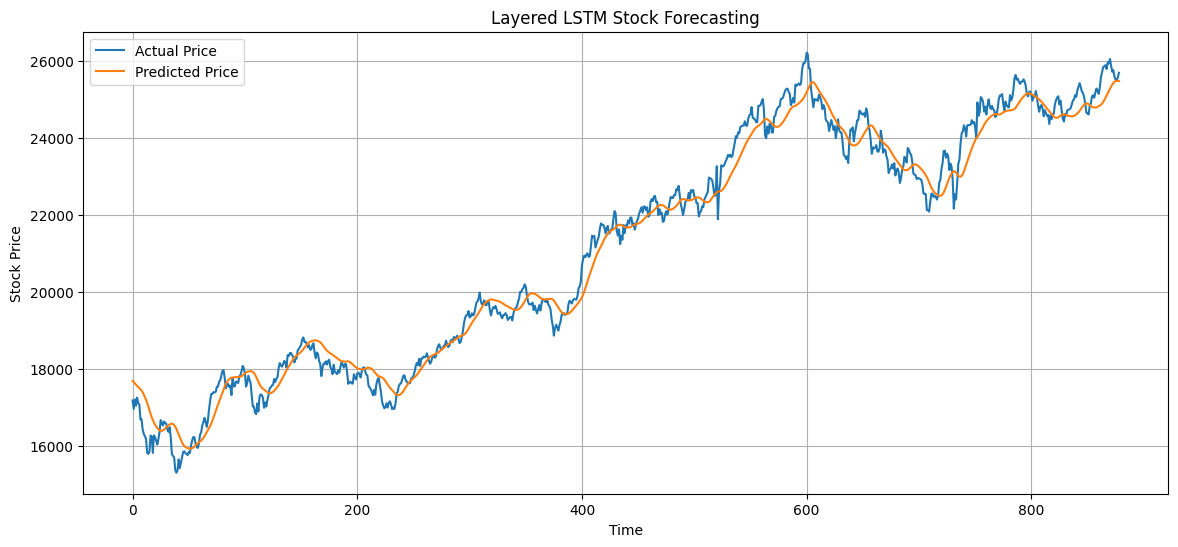

In [34]:
plt.figure(figsize=(14,6))

plt.plot(
    y_test_actual,
    label='Actual Price'
)

plt.plot(
    predictions,
    label='Predicted Price'
)

plt.title('Layered LSTM Stock Forecasting')

plt.xlabel('Time')

plt.ylabel('Stock Price')

plt.legend()

plt.grid(True)

plt.show()

In [35]:
last_60_days = scaled_data[-60:]

future_input = np.reshape(
    last_60_days,
    (1, 60, 1)
)

future_prediction = model.predict(
    future_input
)

future_prediction = scaler.inverse_transform(
    future_prediction
)

print(
    "\nNext Predicted Stock Price:",
    future_prediction[0][0]
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step

Next Predicted Stock Price: 25474.723
